# Working With Geometries

In the course of working with legislative redistricting data, it is inevitable that
we will have to work with files that contain geometries. Most often, these geometries
come in the form of shapefiles, which, while nice in theory, can be a bit of a pain to
work with in practice. For now, we will focus on the basics of working with geometries,
but the interested reader is encouraged to explore our partnered library,
[maup](https://github.com/mggg/maup#readme), which is specifically designed to
help fix tricky geometry problems. Specifically, in the event that you are working with
a shapefile and run in to an error of the flavour:

```console
UserWarning: Found overlaps among the given polygons.
Indices of overlaps: {(887, 892), (893, 915), (892, 914), (887, 893)}
```

or

```console
UserWarning: Found islands (degree-0 nodes). Indices of islands: {2552, 3107}
"Found islands (degree-0 nodes). Indices of islands: {}".format(islands)
```

then you should consider consulting the
[maup documentation](https://github.com/mggg/maup/wiki/)
to see if it can help you out.

## Loading and Running a Plan

<div align="center">
  <a href="https://github.com/mggg/GerryChain/tree/main/docs/_static/MN.zip" class="download-badge" download>Download MN File</a>
</div>
<br style="line-height: 5px;">

For this example, we will make use of a Minnesota GeoJSON file that contains
the geometries of the state's precincts (you will need to unzip the above
folder to get to the file -- it's a bit large). We will follow a similar workflow to
what we already covered in the [ReCom section](./recom.ipynb), but with an eye
towards some of the conveniences afforded by `GeographicPartition` objects. As always,
we'll start with the imports:

In [1]:
import matplotlib.pyplot as plt
from gerrychain import (Partition, Graph, MarkovChain,
                        updaters, constraints, accept,
                        GeographicPartition)
from gerrychain.proposals import build_recom_proposal_fn
from gerrychain.tree import bipartition_tree
from gerrychain.constraints import contiguous
import pandas

And now we load the graph from the GeoJSON file

In [2]:
import zipfile

with zipfile.ZipFile("MN.zip") as z:
    z.extractall()

graph = Graph.from_file("MN_precincts.geojson")

as well as define our updaters and initial partition

In [3]:
my_updaters = {
    "population": updaters.Tally("TOTPOP", alias="population"),
    "cut_edges": updaters.cut_edges,
    "perimeter": updaters.perimeter,
    "area": updaters.Tally("area", alias="area"),
}

initial_partition = GeographicPartition(
    graph,
    assignment="CONGDIST",
    updaters=my_updaters
)

The observant reader will notice that we have added two new updaters, `perimeter`,
and `area`, [^1] and we are now using the `GeographicPartition` class instead of the
`Partition` class. The `GeographicPartition` class is a subclass of the
`Partition` class that allows us the capability of working with geometries throughout
our Markov chain, and the `perimeter` and `area` updaters are examples of such a
geometric updater that was previously unavailable to us. These updaters are necessary for
monitoring things like geometric compactness and area via metrics such as the Polsby-Popper
test. [^2]

And now it is time for one of the first conveniences of the `GeographicPartition` class:
we can plot our map and see the initial partition!

<Axes: >

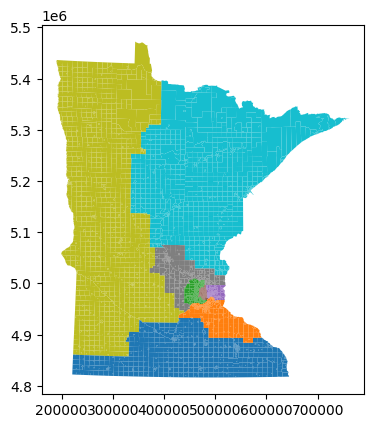

In [4]:
initial_partition.plot()

![Initial Minnesota partition](./images/MN_initial_partition.png)

Of course, this isn't very pretty, so let's pass it some additional arguments to
things a bit nicer:

<Axes: title={'center': 'Initial Partition in MN'}>

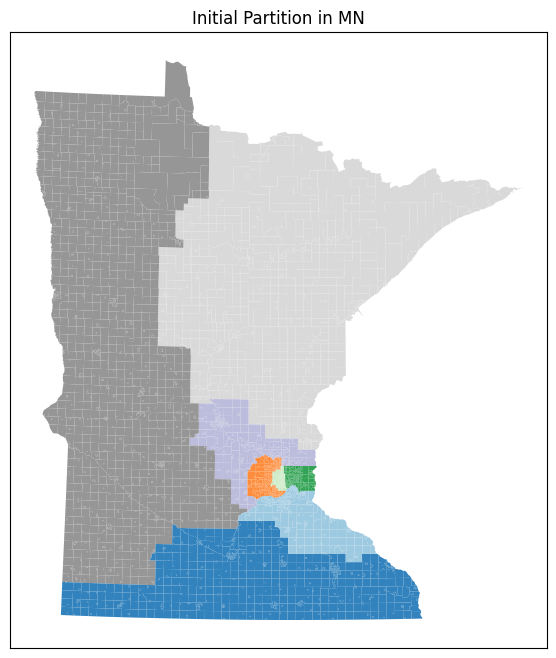

In [5]:
fig, ax = plt.subplots(figsize=(8,8))
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Initial Partition in MN")
initial_partition.plot(ax=ax, cmap='tab20c')

![Initial Minnesota partition with geographic boundaries](./images/MN_initial_partition_pretty.png)

Under the hood, the `plot` method is using the `geodataframe.plot` method from
[geopandas](https://geopandas.org/) to plot the geometries, and all of this is
built on top of `matplotlib`, so most of the standard methods for modifying a
`matplotlib` plot will work here as well.

Now that we have our initial partition, we can run a Markov chain on it just as we
have previously:

In [6]:
ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)


proposal = build_recom_proposal_fn(
    pop_col="TOTPOP",
    pop_target=ideal_population,
    epsilon=0.01,
)

recom_chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=accept.always_accept,
    initial_state=initial_partition,
    total_steps=20,
    rng=42,
)

And the next bit of code will make a fun little widget that will allow us to
watch the chain work!

<!-- not executed: requires ipywidgets, which is not available in the docs execution environment, and widget output does not render in static documentation -->
```python
%matplotlib inline
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png')

import pandas as pd

import matplotlib.cm as mcm
import matplotlib.pyplot as plt
import networkx as nx
from PIL import Image
import io
import ipywidgets as widgets
from IPython.display import display, clear_output

frames = []
district_data = []

for i, partition in enumerate(recom_chain):
    for district_name in partition["perimeter"].keys():
        population = partition["population"][district_name]
        perimeter = partition["perimeter"][district_name]
        area = partition["area"][district_name]
        district_data.append((i, district_name, population, perimeter, area))

    buffer = io.BytesIO()
    fig, ax = plt.subplots(figsize=(10,10))
    partition.plot(ax=ax, cmap='tab20')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.savefig(buffer, format='png', bbox_inches='tight')
    buffer.seek(0)
    image = Image.open(buffer)
    frames.append(image)
    plt.close(fig)

df = pd.DataFrame(
    district_data,
    columns=[
        'step',
        'district_name',
        'population',
        'perimeter',
        'area'
    ]
)

def show_frame(idx):
    clear_output(wait=True)
    display(frames[idx])

slider = widgets.IntSlider(value=0, min=0, max=len(frames)-1, step=1, description='Frame:')
slider.layout.width = '500px'
widgets.interactive(show_frame, idx=slider)
```

which should look something like this:

![Animated Minnesota geographic-partition ensemble](./images/MN_geopartition_ensamble.gif)

and our dataframe has collected all of the data we were interested in:

<!-- not executed: depends on `df` from the widget block above, which is not executed -->
```python
df.head(5)
```

|   | step | district_name | population |   perimeter   |     area     |
|---|------|---------------|------------|---------------|--------------|
| 0 |  0   |       8       |  662998.0  | 1.804646e+06  | 7.807545e+10 |
| 1 |  0   |       6       |  662979.0  | 6.616450e+05  | 7.864760e+09 |
| 2 |  0   |       5       |  662985.0  | 1.133867e+05  | 3.678103e+08 |
| 3 |  0   |       3       |  662994.0  | 2.625007e+05  | 1.509425e+09 |
| 4 |  0   |       7       |  662997.0  | 2.288428e+06  | 9.165192e+10 |

[^1]: The `area` attribute is added when the graph is built from the GeoDataFrame. The
    `perimeter` updater computes district perimeters from the graph's geometries.
[^2]: The Poslby-Popper test is a part of `gerrychain`'s `metrics` submodule
    as well.